In [1]:
# ============================================================
# CELL 1 : CHARGEMENT CORRECT DE TOUS LES FICHIERS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, os

# ============================================================
# Clone PriSTI Repository
# ============================================================

os.chdir("/kaggle/working")
if not os.path.exists("PriSTI"):
    !git clone https://github.com/LMZZML/PriSTI.git
os.chdir("/kaggle/working/PriSTI")
!pwd


BASE_PATH    = "/kaggle/working/PriSTI/data/pm25"
GROUND_PATH  = f"{BASE_PATH}/SampleData/pm25_ground.txt"
MISSING_PATH = f"{BASE_PATH}/SampleData/pm25_missing.txt"
LATLNG_PATH  = f"{BASE_PATH}/SampleData/pm25_latlng.txt"
MEANSTD_PATH = f"{BASE_PATH}/pm25_meanstd.pk"

# ── ground ──
df_ground  = pd.read_csv(GROUND_PATH,  index_col=0, parse_dates=True)
X_ground   = df_ground.values.astype(float)   # (8759, 36)

# ── missing ──
df_missing = pd.read_csv(MISSING_PATH, index_col=0, parse_dates=True)
X          = df_missing.values.astype(float)   # (8759, 36)

# ── latlng  ──  ← FIX : pd.read_csv au lieu de np.loadtxt
df_latlng  = pd.read_csv(LATLNG_PATH)          # header: sensor_id, latitude, longitude
latlng     = df_latlng[["latitude","longitude"]].values.astype(float)  # (36, 2)
sensor_ids = df_latlng["sensor_id"].astype(str).tolist()               # ['001001', ...]

# ── meanstd ──
with open(MEANSTD_PATH, 'rb') as f:
    meanstd = pickle.load(f)

T, N = X.shape   # 8759, 36

print("=" * 55)
print("CHARGEMENT AQI-36 — RÉSUMÉ")
print("=" * 55)
print(f"  X (missing)  : {X.shape}  | NaN : {np.isnan(X).mean()*100:.2f}%")
print(f"  X_ground     : {X_ground.shape}")
print(f"  latlng       : {latlng.shape}")
print(f"  sensor_ids   : {sensor_ids[:5]} ...")
print(f"  meanstd      : {meanstd}")
print(f"  Période      : {df_ground.index[0]} → {df_ground.index[-1]}")

Cloning into 'PriSTI'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 71 (delta 8), reused 6 (delta 6), pack-reused 58 (from 1)
Receiving objects: 100% (71/71), 10.58 MiB | 24.02 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/kaggle/working/PriSTI
CHARGEMENT AQI-36 — RÉSUMÉ
  X (missing)  : (8759, 36)  | NaN : 24.58%
  X_ground     : (8759, 36)
  latlng       : (36, 2)
  sensor_ids   : ['1001', '1002', '1003', '1004', '1005'] ...
  meanstd      : [array([ 88.04281854,  77.92938209,  88.56736666,  88.71378165,
        98.71179764,  88.67111445,  89.36961409,  93.21280037,
        88.86709098,  96.99126638, 102.50229508,  91.19050311,
        90.09942497,  96.59541324,  88.95387244,  95.17416329,
       103.52942413, 103.54660748, 107.85733216,  87.89406221,
        98.73358746,  93.06996916,  84.6442953 ,  79.11060692,
        75.75927846,  79.2323275 ,  74.97939718,  71.02866175,
 

MISSING RATE PAR CAPTEUR
  Min    : 12.1%
  Max    : 39.0%
  Mean   : 24.6%
  Low  (<20%)  : 13 capteurs
  Medium(20-40%): 23 capteurs
  High (>40%)  : 0 capteurs


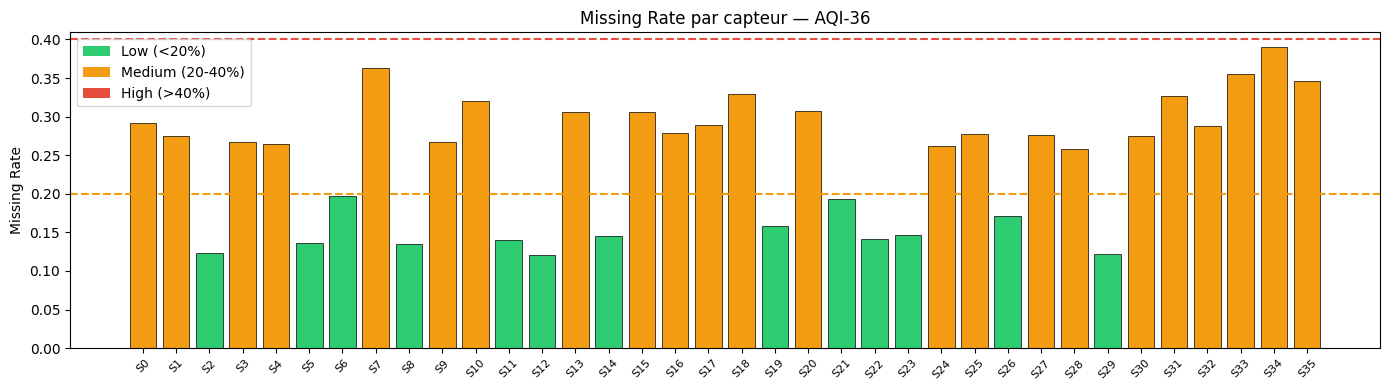

In [2]:
# ============================================================
# CELL 2 : MISSING RATE PAR CAPTEUR
# ============================================================

missing_rates = {}
for i in range(N):
    sid   = sensor_ids[i]
    col   = X[:, i]
    n_nan = int(np.isnan(col).sum())
    rate  = n_nan / T
    missing_rates[sid] = {
        "sensor_id"        : sid,
        "sensor_index"     : i,
        "n_missing"        : n_nan,
        "n_total"          : T,
        "missing_rate"     : round(rate, 4),
        "missing_category" : "low" if rate < 0.2 else "medium" if rate < 0.4 else "high"
    }

rates = [v["missing_rate"] for v in missing_rates.values()]
cats  = [v["missing_category"] for v in missing_rates.values()]

print("MISSING RATE PAR CAPTEUR")
print("=" * 55)
print(f"  Min    : {min(rates)*100:.1f}%")
print(f"  Max    : {max(rates)*100:.1f}%")
print(f"  Mean   : {np.mean(rates)*100:.1f}%")
print(f"  Low  (<20%)  : {cats.count('low')} capteurs")
print(f"  Medium(20-40%): {cats.count('medium')} capteurs")
print(f"  High (>40%)  : {cats.count('high')} capteurs")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#2ecc71' if r < 0.2 else '#f39c12' if r < 0.4 else '#e74c3c' for r in rates]
ax.bar(range(N), rates, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0.2, color='#f39c12', linestyle='--', linewidth=1.5, label='20%')
ax.axhline(0.4, color='#e74c3c', linestyle='--', linewidth=1.5, label='40%')
ax.set_xticks(range(N))
ax.set_xticklabels([f"S{i}" for i in range(N)], rotation=45, fontsize=8)
ax.set_ylabel('Missing Rate')
ax.set_title('Missing Rate par capteur — AQI-36')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='Low (<20%)'),
    Patch(facecolor='#f39c12', label='Medium (20-40%)'),
    Patch(facecolor='#e74c3c', label='High (>40%)')
])
plt.tight_layout()
plt.savefig('missing_rate_aqi36.png', dpi=150)
plt.show()

In [3]:
# ============================================================
# CELL 3 : STATS DE BASE + VARIANCE TEMPORELLE + SMOOTHNESS
# ============================================================

sensor_stats = {}

for i in range(N):
    sid  = sensor_ids[i]
    col  = X[:, i]
    valid = col[~np.isnan(col)]

    # ── Stats de base ──
    mean_v = float(np.nanmean(col)) if len(valid) > 0 else None
    std_v  = float(np.nanstd(col))  if len(valid) > 0 else None
    min_v  = float(np.nanmin(col))  if len(valid) > 0 else None
    max_v  = float(np.nanmax(col))  if len(valid) > 0 else None

    # ── Variance temporelle (fenêtre 24h) ──
    W = 24
    local_vars = []
    for t in range(0, T - W, W // 2):
        win   = col[t:t+W]
        v_win = win[~np.isnan(win)]
        if len(v_win) > W // 2:
            local_vars.append(float(np.var(v_win)))
    temp_var_mean = float(np.mean(local_vars)) if local_vars else None
    temp_var_std  = float(np.std(local_vars))  if local_vars else None

    # ── Smoothness : autocorrélation lag-1 ──
    series = pd.Series(col).interpolate(method='linear', limit_direction='both')
    if len(series.dropna()) > 10:
        ac1  = float(series.autocorr(lag=1))
        ac24 = float(series.autocorr(lag=24))
    else:
        ac1 = ac24 = None

    smooth_label = (
        "smooth"   if ac1 and ac1 > 0.8
        else "moderate" if ac1 and ac1 > 0.5
        else "rough"    if ac1 is not None
        else "unknown"
    )

    # ── Stabilité ──
    all_vars = [float(np.var(X[~np.isnan(X[:, j]), j])) for j in range(N)]
    p33, p66 = np.percentile(all_vars, 33), np.percentile(all_vars, 66)
    stability = (
        "stable"   if temp_var_mean and temp_var_mean < p33
        else "moderate" if temp_var_mean and temp_var_mean < p66
        else "volatile"
    )

    sensor_stats[sid] = {
        "mean"             : round(mean_v, 4) if mean_v else None,
        "std"              : round(std_v,  4) if std_v  else None,
        "min_val"          : round(min_v,  4) if min_v  else None,
        "max_val"          : round(max_v,  4) if max_v  else None,
        "temporal_var_mean": round(temp_var_mean, 4) if temp_var_mean else None,
        "temporal_var_std" : round(temp_var_std,  4) if temp_var_std  else None,
        "stability"        : stability,
        "autocorr_lag1"    : round(ac1,  4) if ac1  else None,
        "autocorr_lag24"   : round(ac24, 4) if ac24 else None,
        "smoothness_label" : smooth_label,
    }

smooth_labels = [v["smoothness_label"] for v in sensor_stats.values()]
stab_labels   = [v["stability"]        for v in sensor_stats.values()]
print("SMOOTHNESS & STABILITÉ")
print("=" * 55)
print(f"  Smooth   (ac1>0.8) : {smooth_labels.count('smooth')}")
print(f"  Moderate (0.5-0.8) : {smooth_labels.count('moderate')}")
print(f"  Rough    (<0.5)    : {smooth_labels.count('rough')}")
print(f"  Stable             : {stab_labels.count('stable')}")
print(f"  Moderate           : {stab_labels.count('moderate')}")
print(f"  Volatile           : {stab_labels.count('volatile')}")

SMOOTHNESS & STABILITÉ
  Smooth   (ac1>0.8) : 36
  Moderate (0.5-0.8) : 0
  Rough    (<0.5)    : 0
  Stable             : 36
  Moderate           : 0
  Volatile           : 0


GPS + DISTANCES
  Distance min  : 1.62 km
  Distance max  : 128.28 km
  Distance mean : 42.25 km


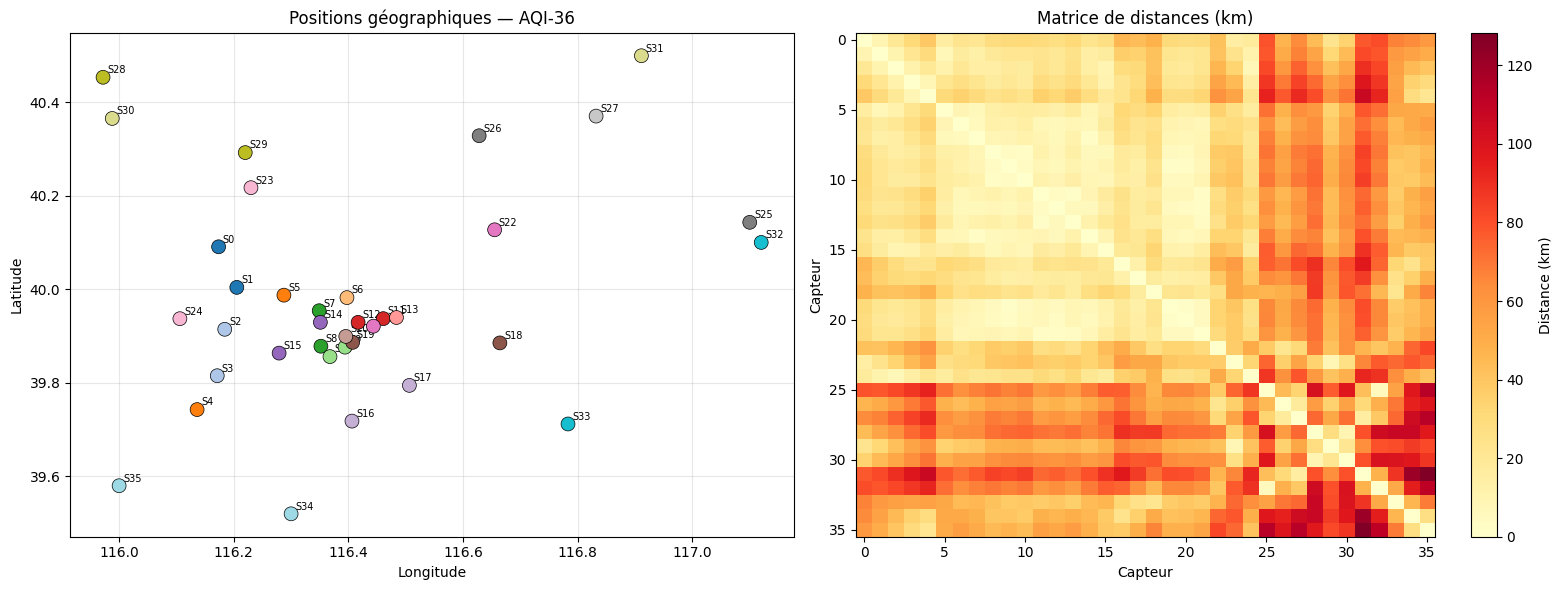

In [4]:
# ============================================================
# CELL 4 : GPS + DISTANCES HAVERSINE
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

# Matrice distances (36x36) en km
dist_matrix = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            dist_matrix[i, j] = haversine(
                latlng[i,0], latlng[i,1],
                latlng[j,0], latlng[j,1]
            )

gps_data = {
    sensor_ids[i]: {
        "latitude" : round(float(latlng[i, 0]), 6),
        "longitude": round(float(latlng[i, 1]), 6)
    } for i in range(N)
}

print("GPS + DISTANCES")
print("=" * 55)
print(f"  Distance min  : {dist_matrix[dist_matrix>0].min():.2f} km")
print(f"  Distance max  : {dist_matrix.max():.2f} km")
print(f"  Distance mean : {dist_matrix[dist_matrix>0].mean():.2f} km")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(latlng[:, 1], latlng[:, 0],
                c=range(N), cmap='tab20', s=100,
                edgecolors='black', linewidth=0.5, zorder=5)
for i in range(N):
    axes[0].annotate(f"S{i}", (latlng[i,1], latlng[i,0]),
                     xytext=(3,3), textcoords='offset points', fontsize=7)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Positions géographiques — AQI-36')
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(dist_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[1], label='Distance (km)')
axes[1].set_title('Matrice de distances (km)')
axes[1].set_xlabel('Capteur')
axes[1].set_ylabel('Capteur')

plt.tight_layout()
plt.savefig('gps_distances_aqi36.png', dpi=150)
plt.show()

CORRÉLATION DE PEARSON
  Seuil                 : 0.7
  Total relations       : 571
  STRONGLY_CORRELATED   : 263
  CORRELATED            : 308


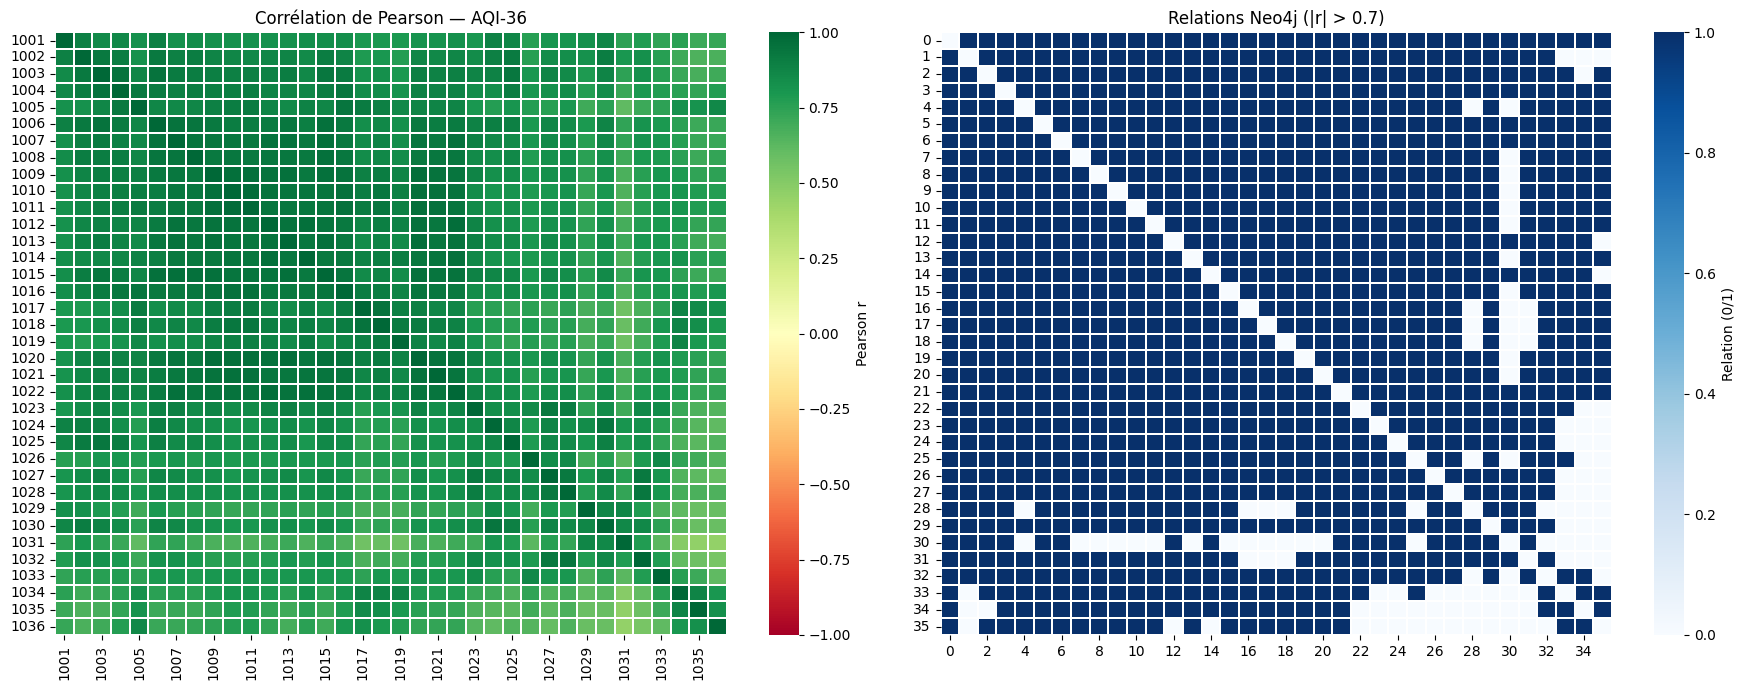

In [5]:
# ============================================================
# CELL 5 : CORRÉLATION DE PEARSON + RELATIONS NEO4J
# ============================================================

CORR_THRESHOLD = 0.7

df_X        = pd.DataFrame(X, columns=sensor_ids)
corr_matrix = df_X.corr(method='pearson')

# Relations pour Neo4j
neo4j_relations = []
for i in range(N):
    for j in range(i+1, N):
        corr_val = float(corr_matrix.iloc[i, j])
        if abs(corr_val) >= CORR_THRESHOLD:
            neo4j_relations.append({
                "source"     : sensor_ids[i],
                "target"     : sensor_ids[j],
                "pearson"    : round(corr_val, 4),
                "weight"     : round(abs(corr_val), 4),
                "distance_km": round(float(dist_matrix[i, j]), 2),
                "rel_type"   : "STRONGLY_CORRELATED" if abs(corr_val) > 0.85 else "CORRELATED"
            })

strong = sum(1 for r in neo4j_relations if r["rel_type"] == "STRONGLY_CORRELATED")
print("CORRÉLATION DE PEARSON")
print("=" * 55)
print(f"  Seuil                 : {CORR_THRESHOLD}")
print(f"  Total relations       : {len(neo4j_relations)}")
print(f"  STRONGLY_CORRELATED   : {strong}")
print(f"  CORRELATED            : {len(neo4j_relations) - strong}")

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr_matrix, ax=axes[0], cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, linewidths=0.3,
            cbar_kws={"label": "Pearson r"})
axes[0].set_title('Corrélation de Pearson — AQI-36')

binary = (np.abs(corr_matrix.values) > CORR_THRESHOLD).astype(int)
np.fill_diagonal(binary, 0)
sns.heatmap(binary, ax=axes[1], cmap='Blues',
            linewidths=0.3, cbar_kws={"label": "Relation (0/1)"})
axes[1].set_title(f'Relations Neo4j (|r| > {CORR_THRESHOLD})')

plt.tight_layout()
plt.savefig('correlation_aqi36.png', dpi=150)
plt.show()

In [6]:
# ============================================================
# CELL 6 : COMPILATION FINALE ET SAUVEGARDE
# ============================================================

OUTPUT_DIR = "/kaggle/working/metadata"
os.makedirs(OUTPUT_DIR, exist_ok=True)

nodes = []
for i in range(N):
    sid  = sensor_ids[i]
    node = {
        "sensor_id"         : sid,
        "sensor_index"      : i,
        "latitude"          : gps_data[sid]["latitude"],
        "longitude"         : gps_data[sid]["longitude"],
        **{k: v for k, v in missing_rates[sid].items()
           if k not in ["sensor_id", "sensor_index"]},
        **sensor_stats[sid],
        "community"         : None,   # rempli après Louvain (Semaine 2)
        "suggested_model"   : None    # rempli après routing  (Semaine 3)
    }
    nodes.append(node)

# Sauvegarde
with open(f"{OUTPUT_DIR}/nodes_metadata.json", 'w') as f:
    json.dump(nodes, f, indent=2)

with open(f"{OUTPUT_DIR}/relations_metadata.json", 'w') as f:
    json.dump(neo4j_relations, f, indent=2)

pd.DataFrame(nodes).to_csv(f"{OUTPUT_DIR}/nodes_metadata.csv", index=False)

corr_matrix.to_csv(f"{OUTPUT_DIR}/correlation_matrix.csv")

pd.DataFrame(dist_matrix,
             index=sensor_ids,
             columns=sensor_ids).to_csv(f"{OUTPUT_DIR}/distance_matrix_km.csv")

print("=" * 55)
print("SAUVEGARDE TERMINÉE")
print("=" * 55)
print(f"  nodes_metadata.json      → {len(nodes)} nœuds")
print(f"  relations_metadata.json  → {len(neo4j_relations)} relations")
print(f"  correlation_matrix.csv   → (36x36)")
print(f"  distance_matrix_km.csv   → (36x36)")
print(f"  nodes_metadata.csv       → résumé lisible")
print(f"\n🎉 JOUR 1-2 TERMINÉ — Prêt pour Jour 3-4 : Neo4j !")

SAUVEGARDE TERMINÉE
  nodes_metadata.json      → 36 nœuds
  relations_metadata.json  → 571 relations
  correlation_matrix.csv   → (36x36)
  distance_matrix_km.csv   → (36x36)
  nodes_metadata.csv       → résumé lisible

🎉 JOUR 1-2 TERMINÉ — Prêt pour Jour 3-4 : Neo4j !
